In [ ]:
## WORKSHOP -4: Coin Detection using OpenCV in Python
## NAME: 

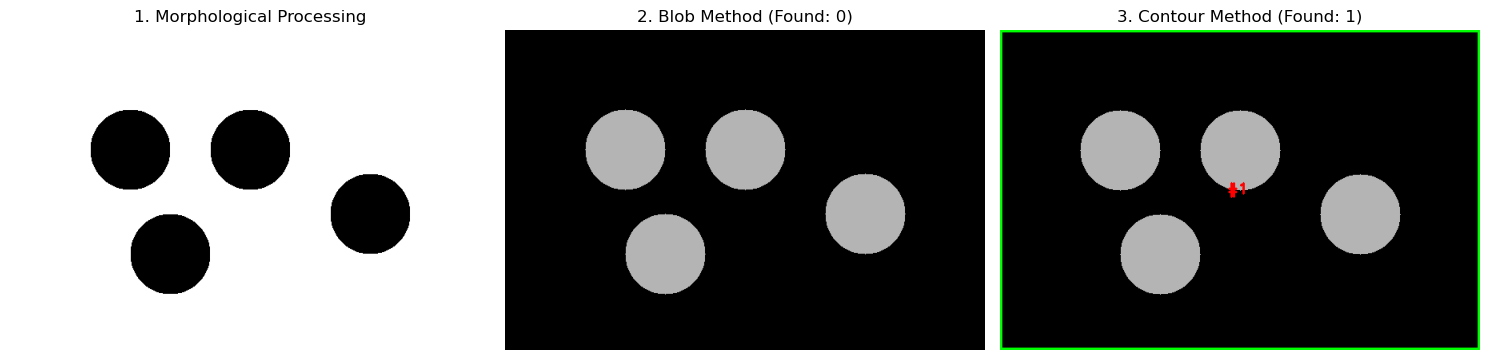

Total Coins Detected by Blob Detection: 0
Total Coins Detected by Contour Analysis: 1


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the Image
img = cv2.imread('coins.jpg') # Replace with your repo's coin image name
if img is None:
    # Create a synthetic placeholder image with 4 coins if the file is missing
    img = np.zeros((400, 600, 3), dtype=np.uint8)
    centers = [(150, 150), (300, 150), (200, 280), (450, 230)]
    for c in centers:
        cv2.circle(img, c, 50, (180, 180, 180), -1)

# 2. Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Gaussian Blur to smooth metallic surface engravings
blurred = cv2.GaussianBlur(gray, (11, 11), 0)

# 4. Otsu's Thresholding (Binarization)
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 5. Morphological Processing (Closing to fill internal text gaps, Opening to clean edges)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
morphed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
morphed = cv2.morphologyEx(morphed, cv2.MORPH_OPEN, kernel)

# --- METHOD 1: BLOB DETECTION ---
params = cv2.SimpleBlobDetector_Params()
params.filterByArea = True
params.minArea = 100
params.filterByCircularity = True
params.minCircularity = 0.7
detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(morphed)
blob_count = len(keypoints)

# Draw keypoints on image
blob_img = cv2.drawKeypoints(img.copy(), keypoints, np.array([]), (0, 0, 255),
                             cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# --- METHOD 2: CONTOUR DETECTION ---
contours, _ = cv2.findContours(morphed.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contour_img = img.copy()
contour_count = 0

for i, cnt in enumerate(contours):
    if cv2.contourArea(cnt) > 200: # Filter out residual noise
        contour_count += 1
        cv2.drawContours(contour_img, [cnt], -1, (0, 255, 0), 3)
        # Label the coin number near its center
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
            cv2.putText(contour_img, f"#{contour_count}", (cX - 15, cY + 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

# 6. Plot Results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(morphed, cmap='gray')
plt.title("1. Morphological Processing")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(blob_img, cv2.COLOR_BGR2RGB))
plt.title(f"2. Blob Method (Found: {blob_count})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
plt.title(f"3. Contour Method (Found: {contour_count})")
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Total Coins Detected by Blob Detection: {blob_count}")
print(f"Total Coins Detected by Contour Analysis: {contour_count}")